In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pynamicalsys import DiscreteDynamicalSystem as dds

In [2]:
ds = dds(model="leonel map")

In [3]:
ds.info

{'description': "Leonel's map model",
 'has_jacobian': True,
 'has_backwards_map': True,
 'mapping': CPUDispatcher(<function leonel_map at 0x1091c5120>),
 'jacobian': CPUDispatcher(<function leonel_map_jacobian at 0x1091c56c0>),
 'backwards_mapping': CPUDispatcher(<function leonel_map_backwards at 0x1091c5440>),
 'dimension': 2,
 'number_of_parameters': 2,
 'parameters': ['eps', 'gamma']}

In [4]:
ds.set_parameters([1e-3, 1])

In [12]:
num_ic = 1000
total_time = int(1e7)
np.random.seed(1312)
x = np.random.uniform(0, 2 * np.pi, num_ic)
y = np.zeros_like(x)
u = np.stack([x, y]).T
sample_times = np.unique(np.logspace(np.log10(1), np.log10(total_time), 1000).astype(int))
num_samples = len(sample_times)

In [13]:
msd = ds.mean_squared_displacement(u, total_time, sample_times=sample_times)

In [14]:
rms = ds.root_mean_squared(u, total_time, sample_times=sample_times)

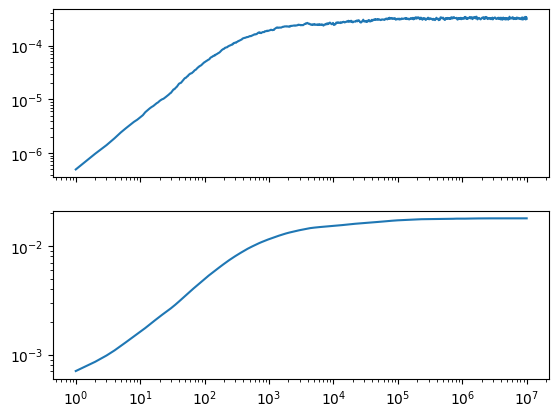

In [15]:
fig, ax = plt.subplots(2, 1, sharex=True)
colors = ["k", "r", "b", "g"]
ax[0].loglog(sample_times, msd)
ax[1].loglog(sample_times, rms)